In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms


# 01 Task

# With tensorflow

In [32]:
# load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [33]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### first version

In [34]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.LeakyReLU(),

    layers.Dense(10)  # 10 classes
])

In [37]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [36]:
model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test)
)


Epoch 1/50
  16/1563 [..............................] - ETA: 10s - loss: 2.3099 - accuracy: 0.0879 

2026-03-25 10:42:11.084287: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


1563/1563 [==============================] - 12s 7ms/step - loss: 2.3076 - accuracy: 0.0895 - val_loss: 2.3030 - val_accuracy: 0.1007
Epoch 2/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2993 - accuracy: 0.1217 - val_loss: 2.2965 - val_accuracy: 0.1341
Epoch 3/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2935 - accuracy: 0.1446 - val_loss: 2.2910 - val_accuracy: 0.1463
Epoch 4/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2879 - accuracy: 0.1585 - val_loss: 2.2852 - val_accuracy: 0.1649
Epoch 5/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2820 - accuracy: 0.1732 - val_loss: 2.2792 - val_accuracy: 0.1771
Epoch 6/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2757 - accuracy: 0.1837 - val_loss: 2.2728 - val_accuracy: 0.1814
Epoch 7/50
1563/1563 [==============================] - 11s 7ms/step - loss: 2.2691 - accuracy: 0.1866 - val_loss: 2.2661 - val_accuracy: 0.1

### second version - with adam

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.LeakyReLU(),

    layers.Dense(10)  # 10 classes
])

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_test, y_test)
)

### third version - with tanh

In [ ]:
# Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.Activation('tanh'),

    layers.Dense(10)
])

# Optimizer Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Entraînement
model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test))

## Results

In [39]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy sur test set :", test_acc)

313/313 [==============================] - 1s 4ms/step - loss: 1.8535 - accuracy: 0.3498
Accuracy sur test set : 0.3497999906539917


## Tensorflow

# with pytorch

In [40]:
import torchvision.transforms as transforms

# transform images and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                
    transforms.Normalize((0.5,0.5,0.5),  
                         (0.5,0.5,0.5))
])

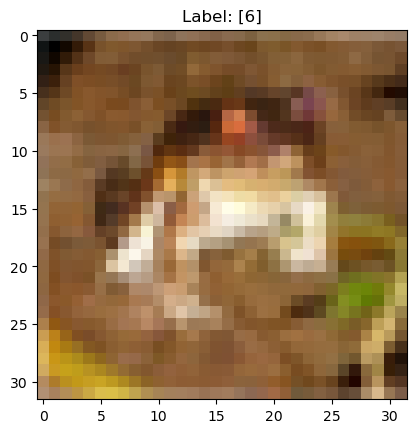

In [41]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

## Upload the data

# 02 Task